In [1]:
import sys
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import os
import numpy as np
import random
sys.path.append("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST")
import torch.nn.functional as F
from cvae_model import CVAE, cvae_loss
from torch.utils.data import Subset

sample_size = 5000 # real data number
filter_threshold = 0.5 # p=0.5

# One-hot encoding helper
def one_hot(labels, num_classes=10):
    return F.one_hot(labels, num_classes).float()

def generate_images_in_batches(model, total_samples, latent_dim, num_classes, batch_size=10000, device='cuda'):
    model.eval()
    generated_images = []
    all_labels = []

    for start in range(0, total_samples, batch_size):
        end = min(start + batch_size, total_samples)
        batch_size_actual = end - start

        # Generate z and y
        z = torch.randn(batch_size_actual, latent_dim).to(device)
        y = torch.arange(num_classes).repeat_interleave(total_samples // num_classes)[start:end]
        y_onehot = F.one_hot(y, num_classes=num_classes).float().to(device)

        with torch.no_grad():
            imgs = model.decode(z, y_onehot).view(-1, 1, 28, 28).cpu()
            generated_images.append(imgs)
            all_labels.append(y)

    images = torch.cat(generated_images, dim=0)
    labels = torch.cat(all_labels, dim=0)
    return images, labels

############################ real data training ############################
seed = 0
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
random.seed(seed)

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Hyperparameters
latent_dim = 20
label_dim = 10
batch_size = 128
epochs = 200
lr = 1e-3
patience = 5

# Load MNIST
transform = transforms.ToTensor()
full_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
train_dataset = Subset(full_dataset, range(sample_size))
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Initialize model
model = CVAE(latent_dim=latent_dim, label_dim=label_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

best_train_loss = float('inf')
trigger_times = 0

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for x, y in train_loader:
        x = x.view(-1, 784).to(device)
        y = one_hot(y).to(device)

        optimizer.zero_grad()
        recon_x, mu, logvar = model(x, y)
        loss = cvae_loss(recon_x, x, mu, logvar)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader.dataset)
    print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {avg_loss:.4f}")

    # Early stopping based on training loss
    if avg_loss < best_train_loss:
        best_train_loss = avg_loss
        trigger_times = 0
    else:
        trigger_times += 1
        print(f"EarlyStopping counter: {trigger_times} out of {patience}")
        if trigger_times >= patience:
            print("Early stopping triggered.")
            break
os.chdir("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST")  
# save the model to model_saved folder
torch.save(model.state_dict(), f"model_saved/cvae_mnist_{sample_size}.pth")
print(f"Model saved to model_saved/cvae_mnist_{sample_size}.pth")

model0_path = f"/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST/model_saved/cvae_mnist_{sample_size}.pth"
############################ generate synthetic data ############################

model = CVAE(latent_dim=latent_dim, label_dim=label_dim)
model.load_state_dict(torch.load(f"model_saved/cvae_mnist_{sample_size}.pth"))
model.eval()

# large sample size for training
latent_dim = model.latent_dim
device = next(model.parameters()).device
gen_imgs_before_filter,y_before_filter = generate_images_in_batches(
    model=model,
    total_samples=6000000,
    latent_dim=latent_dim,
    num_classes=10,
    batch_size=10000,
    device=device
)

############################ filter synthetic data ############################

from discriminator import Discriminator
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
D = Discriminator().to(device)
D.load_state_dict(torch.load("model_saved/discriminator_mnist_cvae_2.pth"))
D.eval()

#data = torch.load(f"data_saved/synthetic_mnist_cvae_{sample_size}.pt")
#synthetic_images = data['images']  

synthetic_loader = DataLoader(gen_imgs_before_filter, batch_size=512)

all_probs = []

with torch.no_grad():
    for batch in synthetic_loader:
        batch = batch.to(device)
        probs = D(batch)  # [batch_size, 1], already sigmoid activated
        all_probs.append(probs.cpu())

all_probs = torch.cat(all_probs, dim=0)
# Flatten probs to shape [N]
probs = all_probs.squeeze(1)

# Load images and labels
images = gen_imgs_before_filter#data['images']      # [N, 1, 28, 28]
labels = y_before_filter #data['labels']      # [N]
# Create mask for p > filter_threshold
mask = probs > filter_threshold

# Apply mask
filtered_images = images[mask]
filtered_labels = labels[mask]

print(f"Selected {filtered_images.shape[0]} samples with p > {filter_threshold}")
# Save to file
torch.save({
    'images': filtered_images,
    'labels': filtered_labels
}, f"data_saved/synthetic_mnist_filtered_pgt{filter_threshold}_{sample_size}.pt")


############################ synthetic data retraining ############################

from torch.utils.data import TensorDataset

images = filtered_images  # shape: [N, 1, 28, 28]
labels = filtered_labels  # shape: [N]

print(f"Loaded {images.shape[0]} filtered synthetic samples")

# Preprocess: flatten images and convert labels to one-hot
images = images.view(-1, 784)  # flatten to [N, 784]

# Create dataset and dataloader
dataset = TensorDataset(images, labels)
train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Initialize model
model = CVAE(latent_dim=latent_dim, label_dim=label_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

best_train_loss = float('inf')
for epoch in range(epochs):
    model.train()
    total_loss = 0

    for x, y in train_loader:
        x = x.view(-1, 784).to(device)
        y = one_hot(y).to(device)

        optimizer.zero_grad()
        recon_x, mu, logvar = model(x, y)
        loss = cvae_loss(recon_x, x, mu, logvar)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader.dataset)
    print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {avg_loss:.4f}")

    # Early stopping based on training loss
    if avg_loss < best_train_loss:
        best_train_loss = avg_loss
        trigger_times = 0
    else:
        trigger_times += 1
        print(f"EarlyStopping counter: {trigger_times} out of {patience}")
        if trigger_times >= patience:
            print("Early stopping triggered.")
            break

# save the model to model_saved folder
torch.save(model.state_dict(), f"model_saved/cvae_mnist_filtered_synthetic_data_{sample_size}.pth")
model1_path = f"model_saved/cvae_mnist_filtered_synthetic_data_{sample_size}.pth"


Epoch [1/200], Train Loss: 289.2108
Epoch [2/200], Train Loss: 203.2987
Epoch [3/200], Train Loss: 180.5909
Epoch [4/200], Train Loss: 163.6566
Epoch [5/200], Train Loss: 153.5960
Epoch [6/200], Train Loss: 147.1924
Epoch [7/200], Train Loss: 142.2007
Epoch [8/200], Train Loss: 138.1660
Epoch [9/200], Train Loss: 135.0459
Epoch [10/200], Train Loss: 131.6477
Epoch [11/200], Train Loss: 128.9189
Epoch [12/200], Train Loss: 126.7101
Epoch [13/200], Train Loss: 124.5109
Epoch [14/200], Train Loss: 122.8315
Epoch [15/200], Train Loss: 121.3991
Epoch [16/200], Train Loss: 120.2449
Epoch [17/200], Train Loss: 119.0302
Epoch [18/200], Train Loss: 117.9980
Epoch [19/200], Train Loss: 116.8348
Epoch [20/200], Train Loss: 115.9087
Epoch [21/200], Train Loss: 115.1816
Epoch [22/200], Train Loss: 114.4127
Epoch [23/200], Train Loss: 113.7345
Epoch [24/200], Train Loss: 112.9594
Epoch [25/200], Train Loss: 112.5227
Epoch [26/200], Train Loss: 111.9417
Epoch [27/200], Train Loss: 111.3447
Epoch [28/

/tmp/ipykernel_2607582/2840644109.py:114: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"model_saved/cvae_mnist_{sample_size}.pth"))
/tmp/i

Selected 61090 samples with p > 0.5
Loaded 61090 filtered synthetic samples
Epoch [1/200], Train Loss: 143.6940
Epoch [2/200], Train Loss: 106.4307
Epoch [3/200], Train Loss: 100.5598
Epoch [4/200], Train Loss: 98.0714
Epoch [5/200], Train Loss: 96.7135
Epoch [6/200], Train Loss: 95.7876
Epoch [7/200], Train Loss: 95.1296
Epoch [8/200], Train Loss: 94.6568
Epoch [9/200], Train Loss: 94.2244
Epoch [10/200], Train Loss: 93.9621
Epoch [11/200], Train Loss: 93.7073
Epoch [12/200], Train Loss: 93.4484
Epoch [13/200], Train Loss: 93.2835
Epoch [14/200], Train Loss: 93.1174
Epoch [15/200], Train Loss: 93.0094
Epoch [16/200], Train Loss: 92.8802
Epoch [17/200], Train Loss: 92.7650
Epoch [18/200], Train Loss: 92.6899
Epoch [19/200], Train Loss: 92.5899
Epoch [20/200], Train Loss: 92.5355
Epoch [21/200], Train Loss: 92.4909
Epoch [22/200], Train Loss: 92.4085
Epoch [23/200], Train Loss: 92.3189
Epoch [24/200], Train Loss: 92.3262
EarlyStopping counter: 1 out of 5
Epoch [25/200], Train Loss: 92.2

# Evaluate

## visualize

/tmp/ipykernel_2607582/3123420589.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model1.load_state_dict(torch.load(model1_path, map_location=device))
/tmp/ipykernel_260

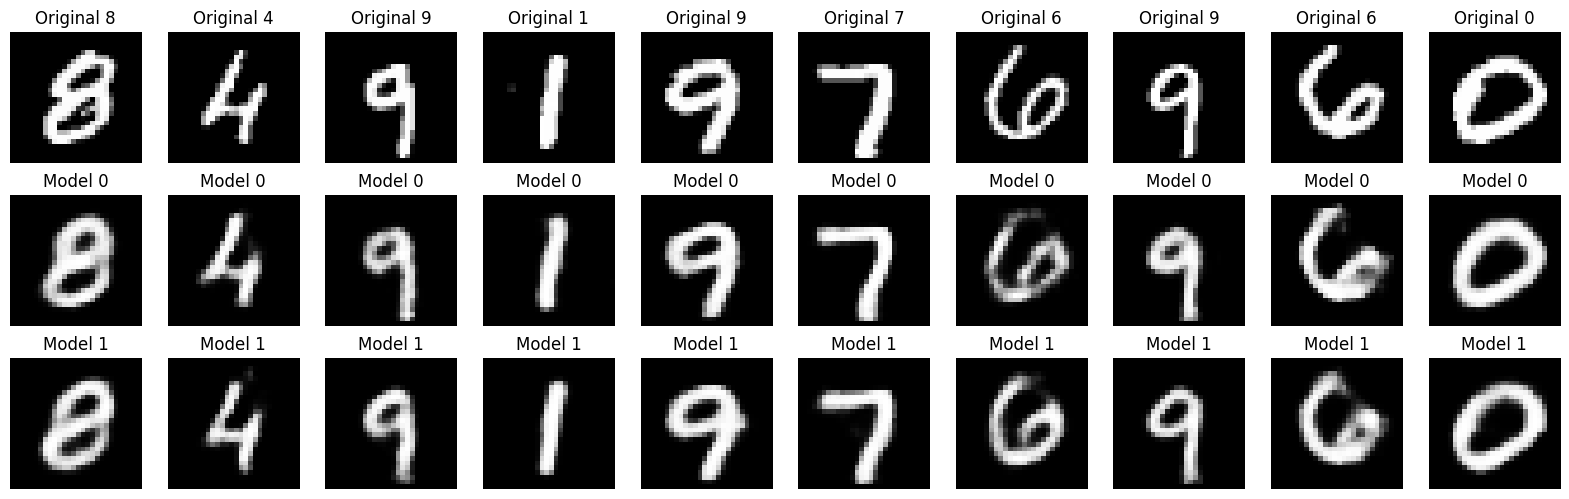

In [2]:
# reconstruct some test data and show the result
model1 = CVAE(latent_dim=latent_dim, label_dim=label_dim).to(device)

model1.load_state_dict(torch.load(model1_path, map_location=device))
model1.eval()

model0 = CVAE(latent_dim=latent_dim, label_dim=label_dim).to(device)
model0.load_state_dict(torch.load(model0_path, map_location=device))
model0.eval()

# Get some test data
test_dataset = datasets.MNIST(root="./data", train=False, transform=transforms.ToTensor())
test_loader = DataLoader(test_dataset, batch_size=10, shuffle=True) # batch size 10 to get 10 samples
data_iter = iter(test_loader)
test_images, test_labels = next(data_iter)
test_images = test_images.view(-1, 784).to(device)  # flatten   to [10, 784]
test_labels_onehot = F.one_hot(test_labels, num_classes=10).float().to(device)  # to one-hot    to [10, 10]     
with torch.no_grad():
    recon_images0, _, _ = model0(test_images, test_labels_onehot)
    recon_images1, _, _ = model1(test_images, test_labels_onehot)
recon_images0 = recon_images0.view(-1, 1, 28, 28).cpu()
recon_images1 = recon_images1.view(-1, 1, 28, 28).cpu()
test_images = test_images.view(-1, 1, 28, 28).cpu() # reshape back to [10, 1, 28, 28]

# Plot original and reconstructed images side by side
fig, axes = plt.subplots(3, 10, figsize=(20, 6))
for i in range(10):
    axes[0, i].imshow(test_images[i].squeeze(), cmap='gray')
    axes[0, i].set_title(f'Original {test_labels[i].item()}')
    axes[0, i].axis('off')
    
    axes[1, i].imshow(recon_images0[i].squeeze(), cmap='gray')
    axes[1, i].set_title('Model 0')
    axes[1, i].axis('off')
    
    axes[2, i].imshow(recon_images1[i].squeeze(), cmap='gray')
    axes[2, i].set_title('Model 1')
    axes[2, i].axis('off')

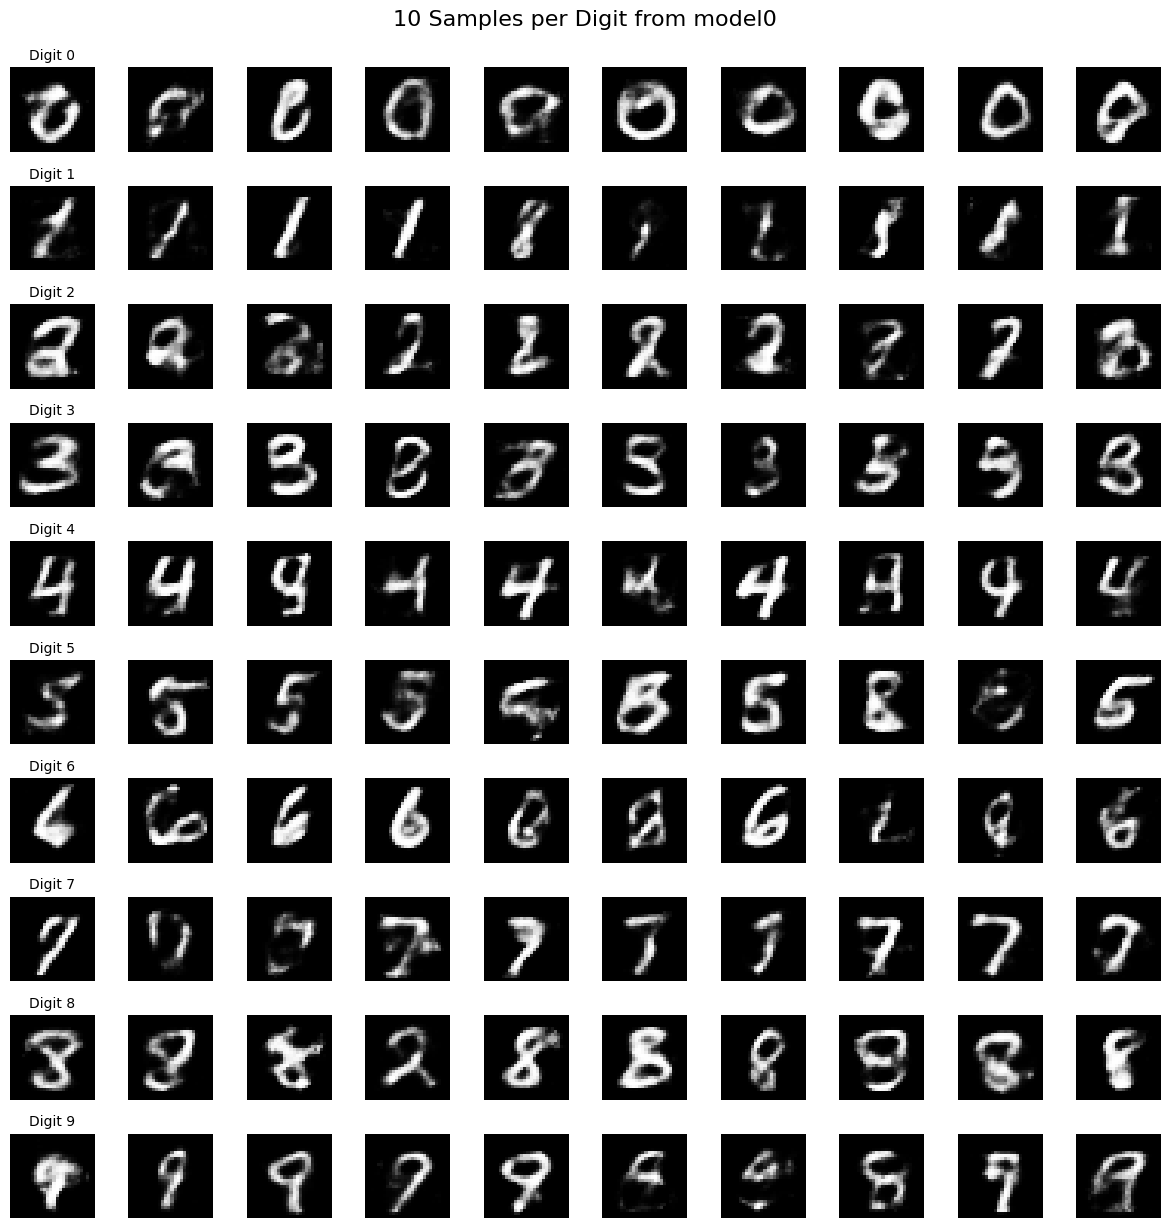

In [3]:
model=model0
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
synthetic_gen_size = 6000
gen_imgs_before_filter,y_before_filter = generate_images_in_batches(
    model=model0,
    total_samples=synthetic_gen_size,
    latent_dim=latent_dim,
    num_classes=10,
    batch_size=10000,
    device=device
)
# Load synthetic data
#synthetic = torch.load(f"data_saved/synthetic_mnist_cvae_{sample_size}_2.pt")
images = gen_imgs_before_filter # [N, 1, 28, 28]
labels = y_before_filter  # [N]

# Ensure on CPU for plotting
images = images.cpu()
labels = labels.cpu()

# Plot 10 samples for each digit
fig, axes = plt.subplots(10, 10, figsize=(12, 12))

for digit in range(10):
    digit_indices = (labels == digit).nonzero(as_tuple=True)[0]
    selected_indices = digit_indices[:10]  # take first 10

    for i, idx in enumerate(selected_indices):
        ax = axes[digit, i]
        ax.imshow(images[idx].squeeze(), cmap="gray")
        ax.axis("off")
        if i == 0:
            ax.set_title(f"Digit {digit}", fontsize=10)

plt.tight_layout()
plt.suptitle("10 Samples per Digit from model0", y=1.02, fontsize=16)
plt.show()


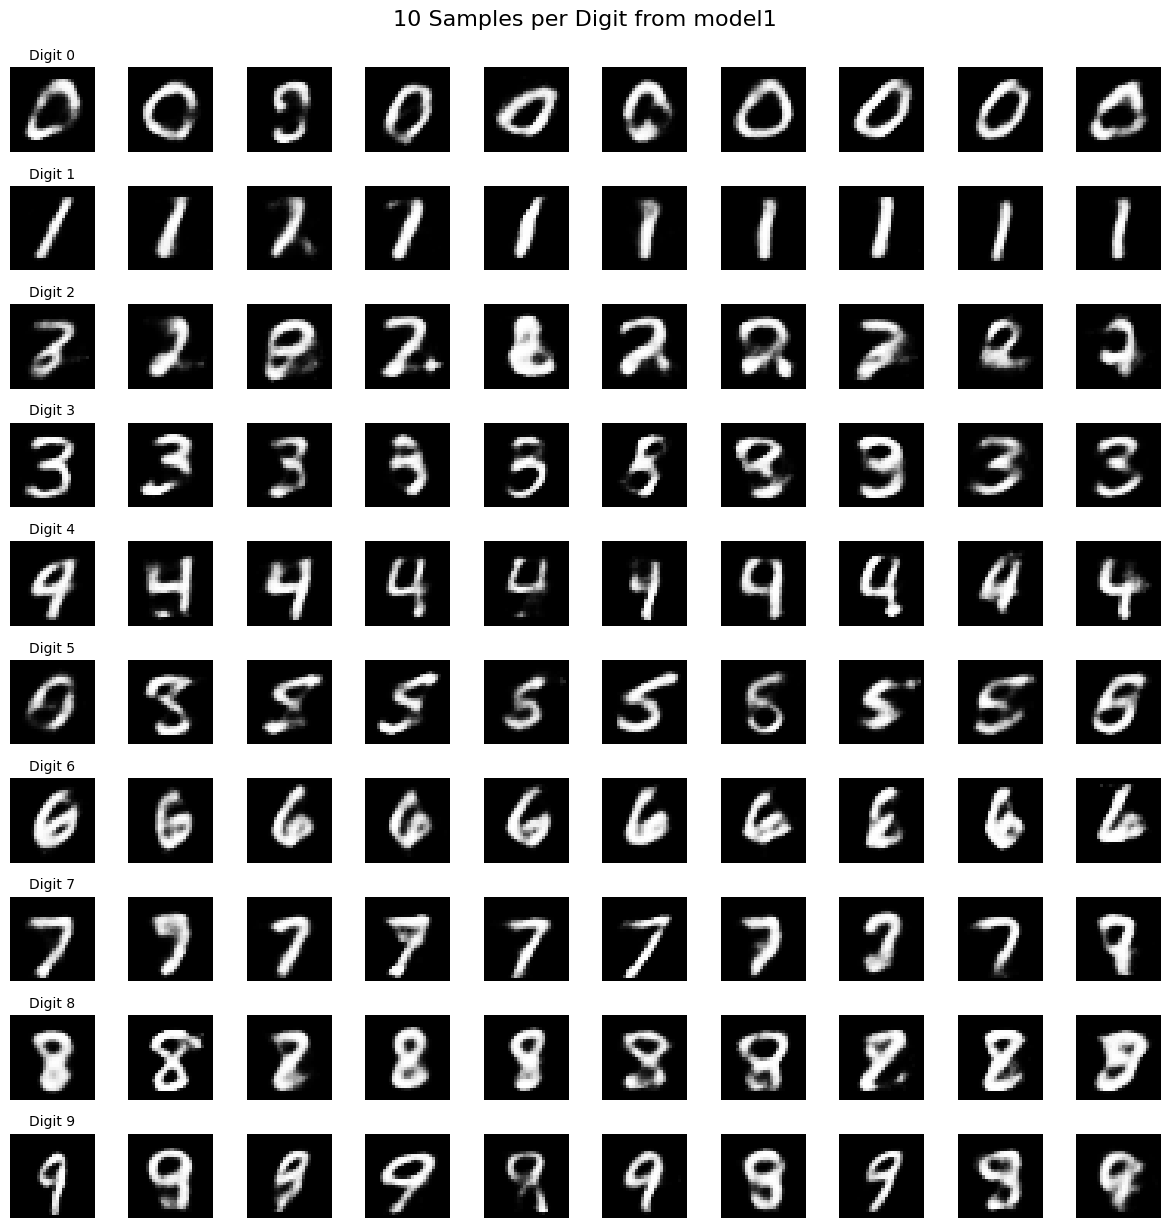

In [4]:
model=model1
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
# large sample size for training


synthetic_gen_size = 6000
# large sample size for training

gen_imgs_before_filter,y_before_filter = generate_images_in_batches(
    model=model1,
    total_samples=synthetic_gen_size,
    latent_dim=latent_dim,
    num_classes=10,
    batch_size=10000,
    device=device
)
# Load synthetic data
#synthetic = torch.load(f"data_saved/synthetic_mnist_cvae_{sample_size}_2.pt")
images = gen_imgs_before_filter # [N, 1, 28, 28]
labels = y_before_filter  # [N]

# Ensure on CPU for plotting
images = images.cpu()
labels = labels.cpu()

# Plot 10 samples for each digit
fig, axes = plt.subplots(10, 10, figsize=(12, 12))

for digit in range(10):
    digit_indices = (labels == digit).nonzero(as_tuple=True)[0]
    selected_indices = digit_indices[:10]  # take first 10

    for i, idx in enumerate(selected_indices):
        ax = axes[digit, i]
        ax.imshow(images[idx].squeeze(), cmap="gray")
        ax.axis("off")
        if i == 0:
            ax.set_title(f"Digit {digit}", fontsize=10)

plt.tight_layout()
plt.suptitle("10 Samples per Digit from model1", y=1.02, fontsize=16)
plt.show()

## Calculate loss

In [5]:
def evaluate_cvae(model, dataloader, device, num_classes=10):
    """
    Evaluate a CVAE model on a given dataloader.

    Args:
        model: The trained CVAE model.
        dataloader: PyTorch DataLoader for evaluation.
        device: torch.device('cuda') or torch.device('cpu').
        num_classes: Number of label classes (default=10).

    Returns:
        dict with average total loss, reconstruction loss (BCE), and KL divergence.
    """
    model.eval()
    total_loss = 0.0
    total_recon_loss = 0.0
    total_kl = 0.0
    num_samples = 0

    with torch.no_grad():
        for x, y in dataloader:
            x = x.view(-1, 784).to(device)
            y = F.one_hot(y, num_classes=num_classes).float().to(device)

            recon_x, mu, logvar = model(x, y)
            BCE = F.binary_cross_entropy(recon_x, x, reduction='sum')
            KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
            loss = BCE + KLD

            total_loss += loss.item()
            total_recon_loss += BCE.item()
            total_kl += KLD.item()
            num_samples += x.size(0)

    return {
        "avg_total_loss": total_loss / num_samples,
        "avg_recon_loss": total_recon_loss / num_samples,
        "avg_kl_divergence": total_kl / num_samples
    }

test_dataset = datasets.MNIST(root="./data", train=False, transform=transforms.ToTensor())
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

model0_score = evaluate_cvae(model0, test_loader, device)
model1_score = evaluate_cvae(model1, test_loader, device)

# save the scores tp compare_result
compare_result = {
    "model0": model0_score,
    "model1": model1_score
}
# Print the scores
print(f"Model 1 (original) scores: {model0_score}")
print(f"Model 2 (filtered synthetic) scores: {model1_score}")


Model 1 (original) scores: {'avg_total_loss': 106.70455018310547, 'avg_recon_loss': 84.88287354736327, 'avg_kl_divergence': 21.821676419067384}
Model 2 (filtered synthetic) scores: {'avg_total_loss': 110.80848142089843, 'avg_recon_loss': 89.74540966796874, 'avg_kl_divergence': 21.06307135925293}


In [7]:
model=model0
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

synthetic_gen_size = 6000
gen_imgs_before_filter,y_before_filter = generate_images_in_batches(
    model=model0,
    total_samples=synthetic_gen_size,
    latent_dim=latent_dim,
    num_classes=10,
    batch_size=10000,
    device=device
)
# Load synthetic data
#synthetic = torch.load(f"data_saved/synthetic_mnist_cvae_{sample_size}_2.pt")
images = gen_imgs_before_filter # [N, 1, 28, 28]
labels = y_before_filter  # [N]

from FID import calculate_fid_score_2

transform = transforms.ToTensor()

real_ds = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
synthetic_ds = TensorDataset(images, labels)
fid_value0 = calculate_fid_score_2(real_ds, synthetic_ds)

In [8]:
model=model1
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

synthetic_gen_size = 6000
gen_imgs_before_filter,y_before_filter = generate_images_in_batches(
    model=model1,
    total_samples=synthetic_gen_size,
    latent_dim=latent_dim,
    num_classes=10,
    batch_size=10000,
    device=device
)
# Load synthetic data
#synthetic = torch.load(f"data_saved/synthetic_mnist_cvae_{sample_size}_2.pt")
images = gen_imgs_before_filter # [N, 1, 28, 28]
labels = y_before_filter  # [N]

from FID import calculate_fid_score_2

transform = transforms.ToTensor()

real_ds = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
synthetic_ds = TensorDataset(images, labels)
fid_value1= calculate_fid_score_2(real_ds, synthetic_ds)

In [9]:
fid_value0, fid_value1

(150.1858367919922, 141.1067657470703)